# FASE 1 — ETL y Validación de Datos
## K-Moda Marketing Mix Modeling · Trabajo IA (UAX)

**Objetivo:** Cargar, limpiar y preparar los 7 datasets originales para las fases siguientes del pipeline MMM.

| Paso | Descripción |
|------|-------------|
| 1 | Carga de los 7 CSV + validación de nulos y tipos |
| 2 | Auditoría bruto vs. neto — demostrar sobreestimación del IVA |
| 3 | Relación 1:N entre PEDIDOS y VENTAS_LINEAS |
| 4 | Rollup Transaccional: ventas semanales nacionales con LEFT JOIN desde CALENDARIO |
| 5 | Preparación `df_inversion_clean` (inversión semanal por canal) |
| 6 | Export a `data/df_ventas_clean.parquet` y `data/df_inversion_clean.parquet` |

> **Regla crítica:** la variable dependiente $Y_t$ es siempre `venta_neta_sin_iva_eur` de VENTAS_LINEAS, nunca `importe_bruto_con_iva_eur` de PEDIDOS.

In [1]:
# ============================================================
# CELDA 1 — IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Paleta corporativa K-Moda ──────────────────────────────
GOLD    = '#C9A84C'
BLACK   = '#1A1A1A'
CREAM   = '#F5F0E8'
DARK    = '#2C2C2C'
GRAY    = '#8C8C8C'
RED_    = '#C0392B'
GREEN_  = '#27AE60'
BLUE_   = '#2980B9'
TEAL_   = '#16A085'
PURPLE_ = '#8E44AD'

COLORS = [
    GOLD, '#5B4A2E', '#8B7355', '#D4B896',
    '#A0856C', '#E8D5B7', '#6B5344', '#9B8B77',
    '#C4A882', '#7A6654',
]

plt.rcParams.update({
    'figure.facecolor' : CREAM,
    'axes.facecolor'   : CREAM,
    'axes.edgecolor'   : BLACK,
    'axes.labelcolor'  : BLACK,
    'xtick.color'      : BLACK,
    'ytick.color'      : BLACK,
    'text.color'       : BLACK,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Rutas ──────────────────────────────────────────────────
PROJECT_DIR = os.path.dirname(os.path.abspath('01_etl.ipynb'))
DATA_DIR    = os.path.join(PROJECT_DIR, 'CASOMAT_MM_07_VENTAS_LINEAS')
IMG_DIR     = os.path.join(PROJECT_DIR, 'img')
OUTPUT_DIR  = os.path.join(PROJECT_DIR, 'data')
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def guardar_img(nombre, fig=None, dpi=150):
    """Guarda figura en img/<nombre>.png con versionado automático."""
    pattern = re.compile(rf'^{re.escape(nombre)}_v(\d+)\.png$')
    existing = [int(m.group(1)) for f in os.listdir(IMG_DIR) if (m := pattern.match(f))]
    v = max(existing) + 1 if existing else 1
    ruta = os.path.join(IMG_DIR, f'{nombre}_v{v:03d}.png')
    (fig or plt.gcf()).savefig(ruta, dpi=dpi, bbox_inches='tight', facecolor=CREAM)
    print(f'  → Guardada: img/{nombre}_v{v:03d}.png')
    return ruta

print('✓ Librerías importadas')
print(f'  PROJECT_DIR : {PROJECT_DIR}')
print(f'  DATA_DIR    : {DATA_DIR}')
print(f'  IMG_DIR     : {IMG_DIR}')
print(f'  OUTPUT_DIR  : {OUTPUT_DIR}')

✓ Librerías importadas
  PROJECT_DIR : /Users/ruben/Desktop/3º INGENIERÍA MATEMÁTICA/2ºCUATRI/INTELIGENCIA ARTIFICIAL/ENTREGA-MARKETING/ENTREGA
  DATA_DIR    : /Users/ruben/Desktop/3º INGENIERÍA MATEMÁTICA/2ºCUATRI/INTELIGENCIA ARTIFICIAL/ENTREGA-MARKETING/ENTREGA/CASOMAT_MM_07_VENTAS_LINEAS
  IMG_DIR     : /Users/ruben/Desktop/3º INGENIERÍA MATEMÁTICA/2ºCUATRI/INTELIGENCIA ARTIFICIAL/ENTREGA-MARKETING/ENTREGA/img
  OUTPUT_DIR  : /Users/ruben/Desktop/3º INGENIERÍA MATEMÁTICA/2ºCUATRI/INTELIGENCIA ARTIFICIAL/ENTREGA-MARKETING/ENTREGA/data


---
## Paso 1 — Carga de los 7 Datasets y Validación de Calidad

In [2]:
# ============================================================
# CELDA 2 — CARGA DE LOS 7 CSV
# ============================================================

clientes      = pd.read_csv(os.path.join(DATA_DIR, 'CASOMAT_MM_01_CLIENTES.csv'))
productos     = pd.read_csv(os.path.join(DATA_DIR, 'CASOMAT_MM_02_PRODUCTOS.csv'))
calendario    = pd.read_csv(os.path.join(DATA_DIR, 'CASOMAT_MM_03_CALENDARIO.csv'))
trafico       = pd.read_csv(os.path.join(DATA_DIR, 'CASOMAT_MM_04_TRAFICO_DIARIO.csv'))
inv_medios    = pd.read_csv(os.path.join(DATA_DIR, 'CASOMAT_MM_05_INVERSION_MEDIOS.csv'))
pedidos       = pd.read_csv(os.path.join(DATA_DIR, 'CASOMAT_MM_06_PEDIDOS.csv'))
ventas_lineas = pd.read_csv(os.path.join(DATA_DIR, 'CASOMAT_MM_07_VENTAS_LINEAS.csv'))

# ── Parseo de fechas ───────────────────────────────────────
calendario   ['fecha']         = pd.to_datetime(calendario   ['fecha'])
trafico      ['fecha']         = pd.to_datetime(trafico      ['fecha'])
inv_medios   ['semana_inicio'] = pd.to_datetime(inv_medios   ['semana_inicio'])
inv_medios   ['semana_fin']    = pd.to_datetime(inv_medios   ['semana_fin'])
pedidos      ['fecha_pedido']  = pd.to_datetime(pedidos      ['fecha_pedido'])
ventas_lineas['fecha_venta']   = pd.to_datetime(ventas_lineas['fecha_venta'])

# ── Resumen de calidad ─────────────────────────────────────
datasets = {
    'CLIENTES'     : clientes,
    'PRODUCTOS'    : productos,
    'CALENDARIO'   : calendario,
    'TRAFICO'      : trafico,
    'INV_MEDIOS'   : inv_medios,
    'PEDIDOS'      : pedidos,
    'VENTAS_LINEAS': ventas_lineas,
}

print('RESUMEN DE DATASETS CARGADOS')
print('=' * 65)
print(f'{"Dataset":<18} {"Filas":>10} {"Cols":>6} {"Nulos":>8} {"Estado"}')
print('-' * 65)
all_ok = True
for nombre, df in datasets.items():
    nulos  = df.isnull().sum().sum()
    estado = '✓' if nulos == 0 else f'⚠ {nulos} nulos'
    if nulos > 0:
        all_ok = False
    print(f'{nombre:<18} {len(df):>10,} {len(df.columns):>6} {nulos:>8} {estado}')

print('=' * 65)
if all_ok:
    print('\n✓ 7 datasets cargados sin nulos')
else:
    print('\n⚠ Se detectaron nulos — revisar antes de continuar')

RESUMEN DE DATASETS CARGADOS
Dataset                 Filas   Cols    Nulos Estado
-----------------------------------------------------------------
CLIENTES              600,000      9        0 ✓
PRODUCTOS                 510      9        0 ✓
CALENDARIO             18,270     18        0 ✓
TRAFICO                18,270     18        0 ✓
INV_MEDIOS             20,880      9        0 ✓
PEDIDOS             8,000,000      9        0 ✓
VENTAS_LINEAS       8,000,000     15        0 ✓

✓ 7 datasets cargados sin nulos


In [3]:
# ============================================================
# CELDA 3 — INSPECCIÓN DE TIPOS Y ESTADÍSTICAS BÁSICAS
# ============================================================

print('INSPECCIÓN DE VENTAS_LINEAS (variable dependiente Yt)')
print('=' * 60)
print(ventas_lineas[['fecha_venta','ciudad','canal_venta','venta_neta_sin_iva_eur']].describe())

print('\nRANGO TEMPORAL POR DATASET')
print('-' * 45)
print(f'  VENTAS_LINEAS : {ventas_lineas["fecha_venta"].min().date()} → {ventas_lineas["fecha_venta"].max().date()}')
print(f'  CALENDARIO    : {calendario["fecha"].min().date()} → {calendario["fecha"].max().date()}')
print(f'  TRAFICO       : {trafico["fecha"].min().date()} → {trafico["fecha"].max().date()}')
print(f'  INV_MEDIOS    : {inv_medios["semana_inicio"].min().date()} → {inv_medios["semana_fin"].max().date()}')

print('\nCIUDADES en VENTAS_LINEAS:')
print(' |', ' | '.join(sorted(ventas_lineas['ciudad'].unique())))

print('\nCANALES DE MEDIO en INV_MEDIOS:')
print(' |', ' | '.join(sorted(inv_medios['canal_medio'].unique())))

INSPECCIÓN DE VENTAS_LINEAS (variable dependiente Yt)
                         fecha_venta  venta_neta_sin_iva_eur
count                        8000000            8.000000e+06
mean   2022-10-30 10:23:27.765599744            9.601128e+01
min              2020-01-01 00:00:00            1.600000e+01
25%              2021-09-21 00:00:00            5.111000e+01
50%              2022-12-14 00:00:00            8.815000e+01
75%              2024-01-14 00:00:00            1.309700e+02
max              2024-12-31 00:00:00            2.400000e+02
std                              NaN            5.312491e+01

RANGO TEMPORAL POR DATASET
---------------------------------------------
  VENTAS_LINEAS : 2020-01-01 → 2024-12-31
  CALENDARIO    : 2020-01-01 → 2024-12-31
  TRAFICO       : 2020-01-01 → 2024-12-31
  INV_MEDIOS    : 2020-01-06 → 2025-01-05

CIUDADES en VENTAS_LINEAS:
 | Barcelona | Bilbao | Madrid | Sevilla | Valencia

CANALES DE MEDIO en INV_MEDIOS:
 | Display | Email CRM | Exterior | Paid S

  → Guardada: img/etl_resumen_calidad_v004.png


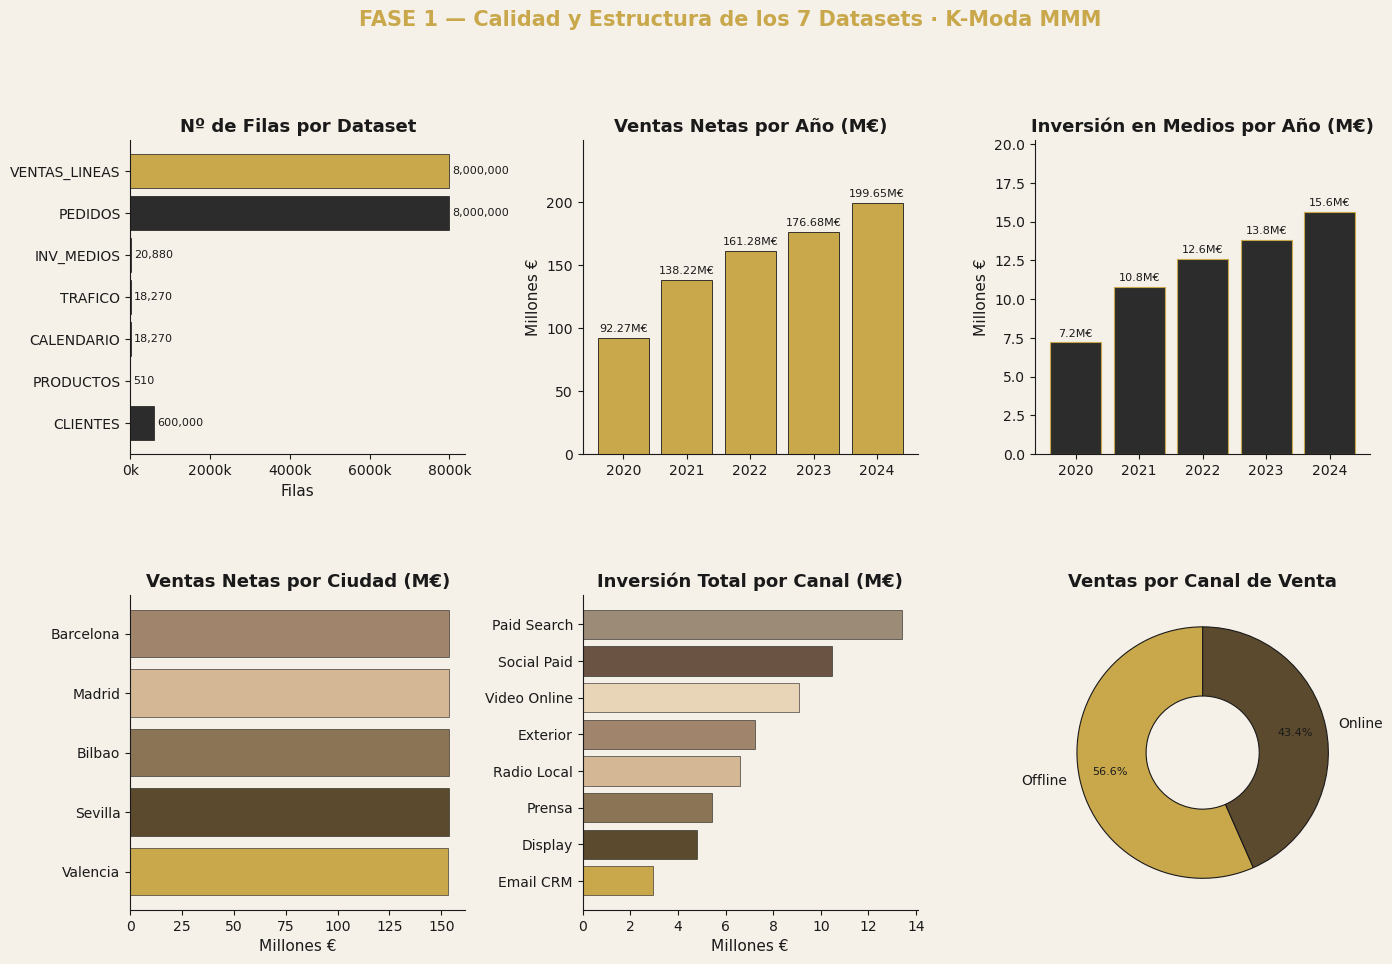

In [4]:
# ============================================================
# CELDA 4 — VISUALIZACIÓN: RESUMEN DE CALIDAD DE DATOS
# ============================================================

fig = plt.figure(figsize=(16, 10), facecolor=CREAM)
fig.suptitle('FASE 1 — Calidad y Estructura de los 7 Datasets · K-Moda MMM',
             fontsize=15, color=GOLD, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Tamaños de datasets (filas)
ax1 = fig.add_subplot(gs[0, 0])
nombres = list(datasets.keys())
tamanios = [len(df) for df in datasets.values()]
colores_bars = [GOLD if n == 'VENTAS_LINEAS' else DARK for n in nombres]
bars = ax1.barh(nombres, tamanios, color=colores_bars, edgecolor=BLACK, linewidth=0.5)
ax1.set_title('Nº de Filas por Dataset', fontweight='bold')
ax1.set_xlabel('Filas')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for bar, v in zip(bars, tamanios):
    ax1.text(v + max(tamanios)*0.01, bar.get_y() + bar.get_height()/2,
             f'{v:,}', va='center', fontsize=8)

# 2. Distribución ventas netas por año
ax2 = fig.add_subplot(gs[0, 1])
ventas_lineas['anio'] = ventas_lineas['fecha_venta'].dt.year
va = ventas_lineas.groupby('anio')['venta_neta_sin_iva_eur'].sum()
bars2 = ax2.bar(va.index, va.values / 1e6, color=GOLD, edgecolor=BLACK, linewidth=0.6)
ax2.bar_label(bars2, fmt='%.2fM€', padding=3, fontsize=8)
ax2.set_title('Ventas Netas por Año (M€)', fontweight='bold')
ax2.set_ylabel('Millones €')
ax2.set_ylim(0, va.max() / 1e6 * 1.25)

# 3. Inversión en medios por año
ax3 = fig.add_subplot(gs[0, 2])
inv_medios['anio_inv'] = inv_medios['semana_inicio'].dt.year
ia = inv_medios[inv_medios['anio_inv'] >= 2020].groupby('anio_inv')['inversion_eur'].sum()
bars3 = ax3.bar(ia.index, ia.values / 1e6, color=DARK, edgecolor=GOLD, linewidth=0.8)
ax3.bar_label(bars3, fmt='%.1fM€', padding=3, fontsize=8)
ax3.set_title('Inversión en Medios por Año (M€)', fontweight='bold')
ax3.set_ylabel('Millones €')
ax3.set_ylim(0, ia.max() / 1e6 * 1.3)

# 4. Ventas por ciudad
ax4 = fig.add_subplot(gs[1, 0])
vc = ventas_lineas.groupby('ciudad')['venta_neta_sin_iva_eur'].sum().sort_values()
ax4.barh(vc.index, vc.values / 1e6,
         color=COLORS[:len(vc)], edgecolor=BLACK, linewidth=0.4)
ax4.set_title('Ventas Netas por Ciudad (M€)', fontweight='bold')
ax4.set_xlabel('Millones €')

# 5. Inversión por canal de medio
ax5 = fig.add_subplot(gs[1, 1])
ic = inv_medios[inv_medios['anio_inv'] >= 2020].groupby('canal_medio')['inversion_eur'].sum().sort_values()
ax5.barh(ic.index, ic.values / 1e6,
         color=COLORS[:len(ic)], edgecolor=BLACK, linewidth=0.4)
ax5.set_title('Inversión Total por Canal (M€)', fontweight='bold')
ax5.set_xlabel('Millones €')

# 6. Ventas por canal de venta
ax6 = fig.add_subplot(gs[1, 2])
vcc = ventas_lineas.groupby('canal_venta')['venta_neta_sin_iva_eur'].sum()
wedges, texts, autotexts = ax6.pie(
    vcc.values, labels=vcc.index, autopct='%1.1f%%',
    colors=COLORS[:len(vcc)], startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor=BLACK, linewidth=0.8, width=0.55)
)
for at in autotexts:
    at.set_fontsize(8)
ax6.set_title('Ventas por Canal de Venta', fontweight='bold')

guardar_img('etl_resumen_calidad', fig)
plt.tight_layout()
plt.show()

---
## Paso 2 — Auditoría Bruto vs. Neto

El enunciado obliga a usar `venta_neta_sin_iva_eur` de VENTAS_LINEAS como variable dependiente $Y_t$.  
Aquí demostramos cuantitativamente que usar el importe bruto con IVA sobreestimaría la señal de forma sistemática.

In [5]:
# ============================================================
# CELDA 5 — AUDITORÍA BRUTO VS. NETO
# ============================================================

total_bruto   = pedidos['importe_bruto_con_iva_eur'].sum()
total_neto_p  = pedidos['importe_neto_sin_iva_eur'].sum()
total_neto_l  = ventas_lineas['venta_neta_sin_iva_eur'].sum()
diff_pct      = (total_bruto - total_neto_l) / total_bruto * 100

print('AUDITORÍA DE LA SEÑAL DE VALOR')
print('=' * 55)
print(f'  Importe BRUTO  con IVA  (PEDIDOS):      {total_bruto:>15,.0f} €')
print(f'  Importe NETO   sin IVA  (PEDIDOS):      {total_neto_p:>15,.0f} €')
print(f'  Venta   NETA   sin IVA  (VENTAS_LINEAS):{total_neto_l:>15,.0f} €')
print(f'  Diferencia bruto → neto:                {diff_pct:>14.1f} %')
print('=' * 55)
print(f'\n→ Usar el bruto SOBREESTIMA Yt en un {diff_pct:.1f}%,')
print(f'  sesgando todos los coeficientes β del modelo.')

# ── Relación 1:N entre PEDIDOS y VENTAS_LINEAS ─────────────
print('\nRELACIÓN 1:N  PEDIDOS → VENTAS_LINEAS')
print('-' * 45)
lineas_por_pedido = ventas_lineas.groupby('id_pedido').size()
print(f'  Total pedidos en VENTAS_LINEAS : {lineas_por_pedido.index.nunique():>10,}')
print(f'  Total pedidos en PEDIDOS       : {len(pedidos):>10,}')
print(f'  Líneas por pedido  — media     : {lineas_por_pedido.mean():>10.2f}')
print(f'  Líneas por pedido  — máximo    : {lineas_por_pedido.max():>10}')
print(f'  Pedidos con 1 línea  : {(lineas_por_pedido==1).sum():,}  ({(lineas_por_pedido==1).mean()*100:.1f}%)')
print(f'  Pedidos con >3 líneas: {(lineas_por_pedido>3).sum():,}  ({(lineas_por_pedido>3).mean()*100:.1f}%)')
print('\n✓ Relación 1:N confirmada — VENTAS_LINEAS es el nivel correcto para Yt')

AUDITORÍA DE LA SEÑAL DE VALOR
  Importe BRUTO  con IVA  (PEDIDOS):          800,069,486 €
  Importe NETO   sin IVA  (PEDIDOS):          768,090,254 €
  Venta   NETA   sin IVA  (VENTAS_LINEAS):    768,090,254 €
  Diferencia bruto → neto:                           4.0 %

→ Usar el bruto SOBREESTIMA Yt en un 4.0%,
  sesgando todos los coeficientes β del modelo.

RELACIÓN 1:N  PEDIDOS → VENTAS_LINEAS
---------------------------------------------
  Total pedidos en VENTAS_LINEAS :  8,000,000
  Total pedidos en PEDIDOS       :  8,000,000
  Líneas por pedido  — media     :       1.00
  Líneas por pedido  — máximo    :          1
  Pedidos con 1 línea  : 8,000,000  (100.0%)
  Pedidos con >3 líneas: 0  (0.0%)

✓ Relación 1:N confirmada — VENTAS_LINEAS es el nivel correcto para Yt


  → Guardada: img/auditoria_senal_valor_v004.png


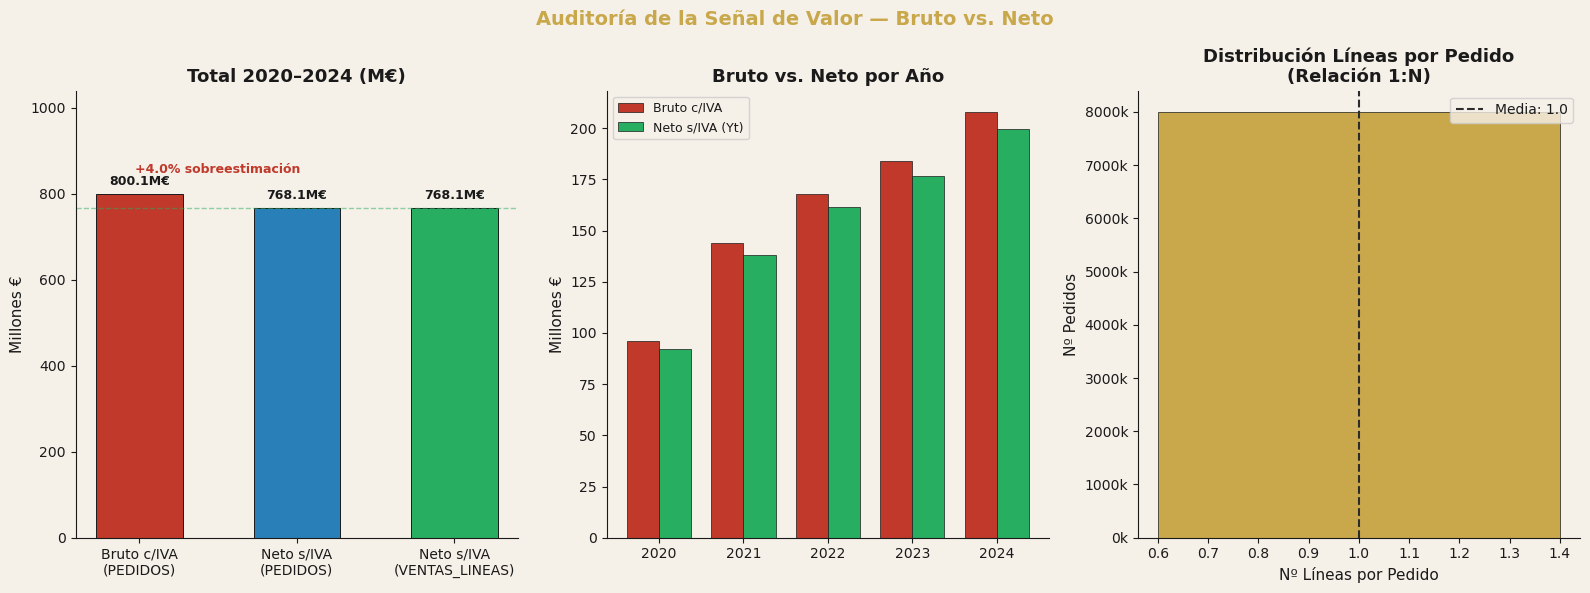

In [6]:
# ============================================================
# CELDA 6 — VISUALIZACIÓN: AUDITORÍA BRUTO VS NETO
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=CREAM)
fig.suptitle('Auditoría de la Señal de Valor — Bruto vs. Neto',
             fontsize=14, color=GOLD, fontweight='bold')

# 1. Comparativa global bruto / neto
ax = axes[0]
labels = ['Bruto c/IVA\n(PEDIDOS)', 'Neto s/IVA\n(PEDIDOS)', 'Neto s/IVA\n(VENTAS_LINEAS)']
valores = [total_bruto, total_neto_p, total_neto_l]
barcolors = [RED_, BLUE_, GREEN_]
bars = ax.bar(labels, [v / 1e6 for v in valores],
              color=barcolors, edgecolor=BLACK, linewidth=0.7, width=0.55)
ax.bar_label(bars, fmt='%.1fM€', padding=4, fontsize=9, fontweight='bold')
ax.set_title('Total 2020–2024 (M€)', fontweight='bold')
ax.set_ylabel('Millones €')
ax.set_ylim(0, max(valores) / 1e6 * 1.3)
ax.axhline(total_neto_l / 1e6, color=GREEN_, linestyle='--', alpha=0.5, linewidth=1)
ax.text(0.5, total_bruto / 1e6 * 1.06,
        f'+{diff_pct:.1f}% sobreestimación', ha='center', fontsize=9,
        color=RED_, fontweight='bold')

# 2. Diferencia bruto vs neto por año
ax2 = axes[1]
ped_anio = pedidos.copy()
ped_anio['anio'] = ped_anio['fecha_pedido'].dt.year
bruto_a = ped_anio.groupby('anio')['importe_bruto_con_iva_eur'].sum()
vl_a    = ventas_lineas.groupby('anio')['venta_neta_sin_iva_eur'].sum()
x = np.arange(len(bruto_a))
w = 0.38
ax2.bar(x - w/2, bruto_a.values / 1e6, w, color=RED_,    edgecolor=BLACK, linewidth=0.5, label='Bruto c/IVA')
ax2.bar(x + w/2, vl_a.reindex(bruto_a.index, fill_value=0).values / 1e6, w,
        color=GREEN_, edgecolor=BLACK, linewidth=0.5, label='Neto s/IVA (Yt)')
ax2.set_xticks(x)
ax2.set_xticklabels(bruto_a.index)
ax2.set_title('Bruto vs. Neto por Año', fontweight='bold')
ax2.set_ylabel('Millones €')
ax2.legend(fontsize=9)

# 3. Distribución de líneas por pedido
ax3 = axes[2]
dist_lineas = lineas_por_pedido.value_counts().sort_index().head(10)
ax3.bar(dist_lineas.index, dist_lineas.values,
        color=GOLD, edgecolor=BLACK, linewidth=0.5)
ax3.set_title('Distribución Líneas por Pedido\n(Relación 1:N)', fontweight='bold')
ax3.set_xlabel('Nº Líneas por Pedido')
ax3.set_ylabel('Nº Pedidos')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
mean_l = lineas_por_pedido.mean()
ax3.axvline(mean_l, color=DARK, linestyle='--', linewidth=1.5, label=f'Media: {mean_l:.1f}')
ax3.legend()

plt.tight_layout()
guardar_img('auditoria_senal_valor', fig)
plt.show()

---
## Paso 3 — Rollup Transaccional

### Justificación de la granularidad semanal nacional

El MMM estándar opera a nivel **nacional y semanal** porque:
1. La **inversión en medios** es una decisión nacional (no por ciudad)
2. El efecto de los medios se mide sobre ventas agregadas nacionales
3. La granularidad semanal evita el ruido del día a día
4. Mantiene suficientes observaciones (~261 semanas = 5 años)

### Protocolo LEFT JOIN

La **tabla raíz** es siempre CALENDARIO (nunca VENTAS_LINEAS). Así, las semanas sin ventas aparecen como $Y_t = 0$ en lugar de desaparecer del dataset.

In [7]:
# ============================================================
# CELDA 7 — ROLLUP TRANSACCIONAL: VENTAS SEMANALES NACIONALES
# ============================================================

# Paso A: Período semanal en ventas
ventas_lineas['semana'] = ventas_lineas['fecha_venta'].dt.to_period('W')

# Paso B: Rollup intermedio (semana × ciudad) — para verificación del spec
ventas_ciudad_semanal = (
    ventas_lineas
    .groupby(['semana', 'ciudad'])['venta_neta_sin_iva_eur']
    .sum()
    .reset_index()
    .rename(columns={'venta_neta_sin_iva_eur': 'Yt'})
)
n_semanas_rollup = ventas_ciudad_semanal['semana'].nunique()
n_ciudades_rollup = ventas_ciudad_semanal['ciudad'].nunique()
print(f'  Rollup intermedio (semana × ciudad): {n_semanas_rollup} semanas × {n_ciudades_rollup} ciudades = {len(ventas_ciudad_semanal):,} filas')

# Paso C: Aggregación nacional (sumar todas las ciudades por semana)
ventas_weekly = (
    ventas_lineas
    .groupby('semana')['venta_neta_sin_iva_eur']
    .sum()
    .reset_index()
    .rename(columns={'venta_neta_sin_iva_eur': 'Yt'})
)

# Paso D: Calendario semanal nacional
FLAG_COLS = [
    'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag',
    'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag',
    'fin_de_semana', 'incidencia_ecommerce_flag',
]
NUM_COLS = ['temperatura_media_c', 'lluvia_indice', 'turismo_indice']

calendario['semana'] = calendario['fecha'].dt.to_period('W')
cal_weekly = (
    calendario
    .groupby('semana')
    .agg({**{c: 'max' for c in FLAG_COLS}, **{c: 'mean' for c in NUM_COLS}})
    .reset_index()
)

# Paso E: Tráfico semanal nacional
trafico['semana'] = trafico['fecha'].dt.to_period('W')
trafico_weekly = (
    trafico
    .groupby('semana')
    .agg(visitas_tienda=('visitas_tienda', 'sum'),
         sesiones_web  =('sesiones_web',   'sum'))
    .reset_index()
)

# Paso F: LEFT JOIN desde CALENDARIO semanal como tabla raíz
base_ventas = cal_weekly.merge(ventas_weekly, on='semana', how='left')
base_ventas['Yt'] = base_ventas['Yt'].fillna(0)
base_ventas = base_ventas.merge(trafico_weekly, on='semana', how='left')

# Columnas auxiliares de tiempo
base_ventas['semana_dt'] = base_ventas['semana'].dt.to_timestamp()
base_ventas['anio']      = base_ventas['semana_dt'].dt.year
base_ventas['mes']       = base_ventas['semana_dt'].dt.month
base_ventas['semana_num']= base_ventas['semana_dt'].dt.isocalendar().week.astype(int)

# Filtrar 2020-2024 y ordenar cronológicamente
base_ventas = (
    base_ventas
    [(base_ventas['anio'] >= 2020) & (base_ventas['anio'] <= 2024)]
    .sort_values('semana_dt')
    .reset_index(drop=True)
)

print(f'\n✓ Dataset semanal nacional: {len(base_ventas)} semanas × {len(base_ventas.columns)} columnas')
print(f'  Período: {base_ventas["semana_dt"].min().date()} → {base_ventas["semana_dt"].max().date()}')
print(f'  Yt semanal — media: {base_ventas["Yt"].mean():,.0f}€  std: {base_ventas["Yt"].std():,.0f}€')
print(f'  Semanas con Yt = 0 : {(base_ventas["Yt"]==0).sum()}')
print(f'\n  Columnas: {list(base_ventas.columns)}')

  Rollup intermedio (semana × ciudad): 262 semanas × 5 ciudades = 1,310 filas

✓ Dataset semanal nacional: 261 semanas × 20 columnas
  Período: 2020-01-06 → 2024-12-30
  Yt semanal — media: 2,937,933€  std: 709,206€
  Semanas con Yt = 0 : 0

  Columnas: ['semana', 'payday_flag', 'rebajas_flag', 'black_friday_flag', 'navidad_flag', 'semana_santa_flag', 'vacaciones_escolares_flag', 'festivo_local_flag', 'fin_de_semana', 'incidencia_ecommerce_flag', 'temperatura_media_c', 'lluvia_indice', 'turismo_indice', 'Yt', 'visitas_tienda', 'sesiones_web', 'semana_dt', 'anio', 'mes', 'semana_num']


  → Guardada: img/etl_rollup_yt_v004.png


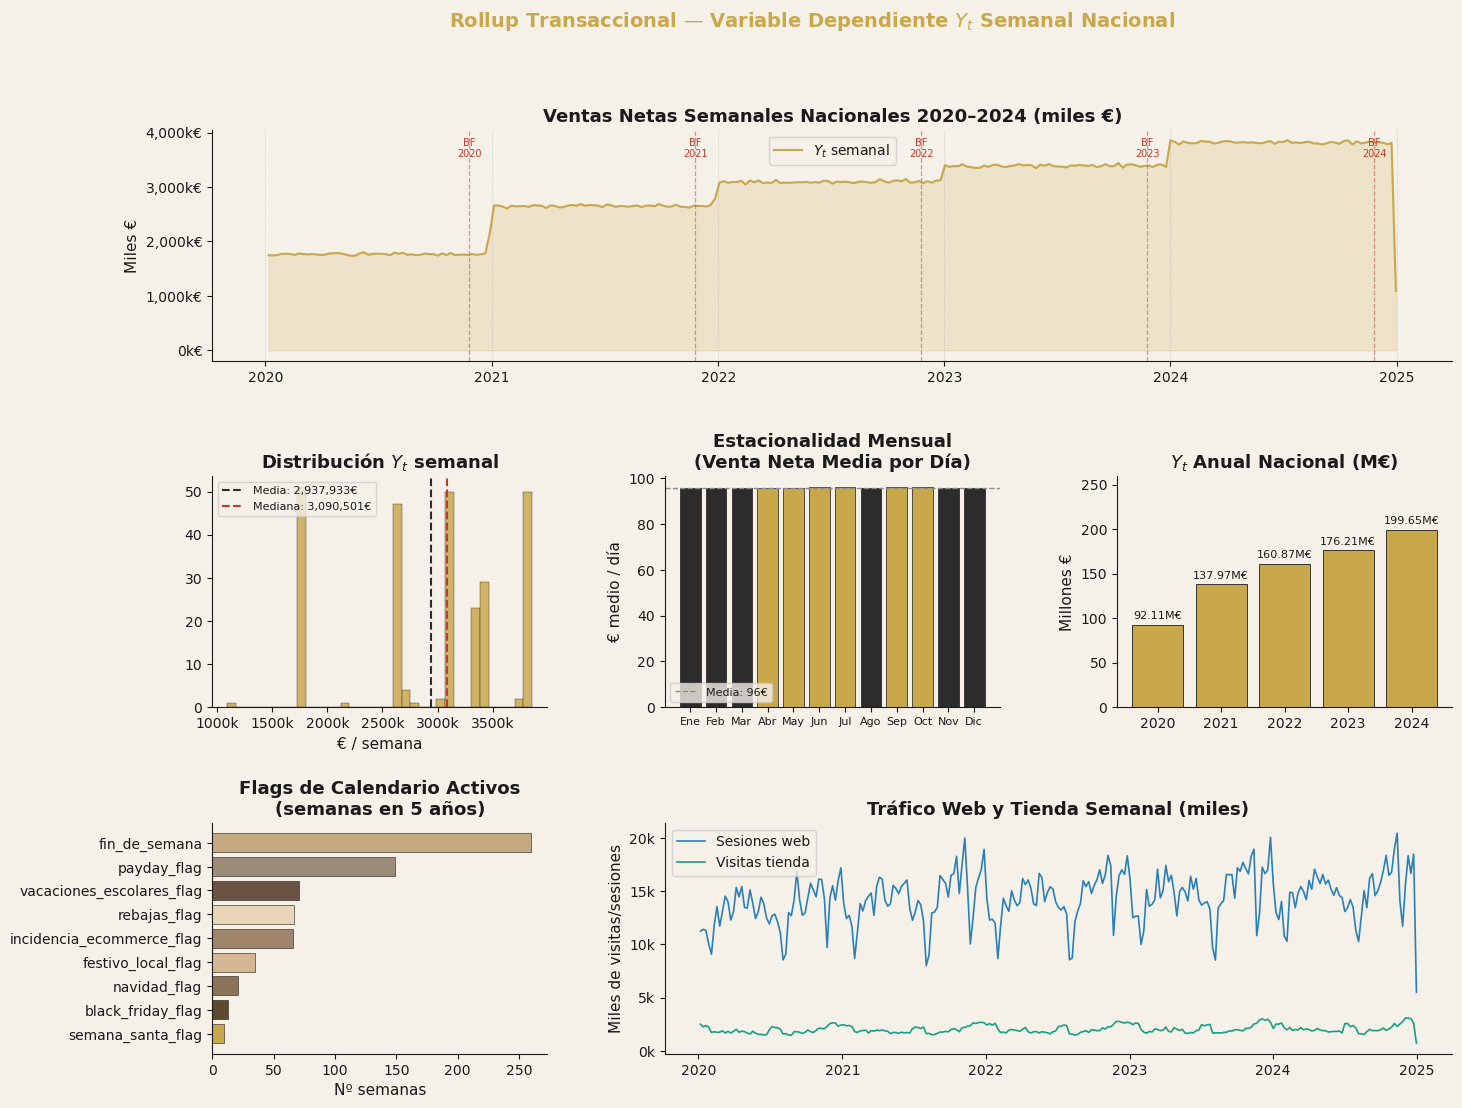

In [8]:
# ============================================================
# CELDA 8 — VISUALIZACIÓN: SEÑAL Yt Y CALENDARIO
# ============================================================

fig = plt.figure(figsize=(16, 12), facecolor=CREAM)
fig.suptitle('Rollup Transaccional — Variable Dependiente $Y_t$ Semanal Nacional',
             fontsize=14, color=GOLD, fontweight='bold')

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# 1. Serie temporal Yt semanal (panel superior ancho)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(base_ventas['semana_dt'], base_ventas['Yt'] / 1e3,
         color=GOLD, linewidth=1.5, label='$Y_t$ semanal')
ax1.fill_between(base_ventas['semana_dt'], base_ventas['Yt'] / 1e3,
                 alpha=0.18, color=GOLD)
# Marcar Black Fridays
for yr in range(2020, 2025):
    bf_date = pd.Timestamp(f'{yr}-11-25')
    ax1.axvline(bf_date, color=RED_, linestyle='--', alpha=0.5, linewidth=0.9)
    ax1.text(bf_date, base_ventas['Yt'].max() / 1e3 * 0.92,
             f'BF\n{yr}', fontsize=7, color=RED_, ha='center')
# Marcar años
for yr in range(2020, 2026):
    ax1.axvline(pd.Timestamp(f'{yr}-01-01'), color=GRAY, linestyle=':', alpha=0.4, linewidth=0.7)
ax1.set_title('Ventas Netas Semanales Nacionales 2020–2024 (miles €)', fontweight='bold')
ax1.set_ylabel('Miles €')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k€'))
ax1.legend()

# 2. Distribución Yt (semanas con ventas)
ax2 = fig.add_subplot(gs[1, 0])
yt_nz = base_ventas[base_ventas['Yt'] > 0]['Yt']
ax2.hist(yt_nz, bins=35, color=GOLD, edgecolor=BLACK, linewidth=0.3, alpha=0.85)
ax2.axvline(yt_nz.mean(),   color=DARK,  linestyle='--', linewidth=1.5,
            label=f'Media: {yt_nz.mean():,.0f}€')
ax2.axvline(yt_nz.median(), color=RED_,  linestyle='--', linewidth=1.5,
            label=f'Mediana: {yt_nz.median():,.0f}€')
ax2.set_title('Distribución $Y_t$ semanal', fontweight='bold')
ax2.set_xlabel('€ / semana')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# 3. Estacionalidad mensual
ax3 = fig.add_subplot(gs[1, 1])
ventas_mes = ventas_lineas.groupby(ventas_lineas['fecha_venta'].dt.month)['venta_neta_sin_iva_eur'].mean()
meses_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
colores_mes = [GOLD if v >= ventas_mes.mean() else DARK for v in ventas_mes.values]
ax3.bar(range(1, 13), ventas_mes.values, color=colores_mes, edgecolor=BLACK, linewidth=0.5)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(meses_labels, fontsize=8)
ax3.set_title('Estacionalidad Mensual\n(Venta Neta Media por Día)', fontweight='bold')
ax3.set_ylabel('€ medio / día')
ax3.axhline(ventas_mes.mean(), color=GRAY, linestyle='--', linewidth=1,
            label=f'Media: {ventas_mes.mean():,.0f}€')
ax3.legend(fontsize=8)

# 4. Yt anual (barras)
ax4 = fig.add_subplot(gs[1, 2])
yt_anio = base_ventas.groupby('anio')['Yt'].sum()
bars4 = ax4.bar(yt_anio.index, yt_anio.values / 1e6,
                color=GOLD, edgecolor=BLACK, linewidth=0.6)
ax4.bar_label(bars4, fmt='%.2fM€', padding=3, fontsize=8)
ax4.set_title('$Y_t$ Anual Nacional (M€)', fontweight='bold')
ax4.set_ylabel('Millones €')
ax4.set_ylim(0, yt_anio.max() / 1e6 * 1.3)

# 5. Flags de calendario activos por semana
ax5 = fig.add_subplot(gs[2, 0])
flag_counts = base_ventas[FLAG_COLS].sum().sort_values(ascending=True)
ax5.barh(flag_counts.index, flag_counts.values,
         color=COLORS[:len(flag_counts)], edgecolor=BLACK, linewidth=0.4)
ax5.set_title('Flags de Calendario Activos\n(semanas en 5 años)', fontweight='bold')
ax5.set_xlabel('Nº semanas')

# 6. Tráfico web + tienda semanal
ax6 = fig.add_subplot(gs[2, 1:])
ax6.plot(base_ventas['semana_dt'], base_ventas['sesiones_web'] / 1e3,
         color=BLUE_, linewidth=1.2, label='Sesiones web')
ax6.plot(base_ventas['semana_dt'], base_ventas['visitas_tienda'] / 1e3,
         color=TEAL_, linewidth=1.2, label='Visitas tienda')
ax6.set_title('Tráfico Web y Tienda Semanal (miles)', fontweight='bold')
ax6.set_ylabel('Miles de visitas/sesiones')
ax6.legend()
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))

guardar_img('etl_rollup_yt', fig)
plt.tight_layout()
plt.show()

---
## Paso 4 — Preparación de Inversión en Medios (`df_inversion_clean`)

La inversión en medios está en formato largo (una fila por ciudad × semana × canal). La limpiamos y la dejamos en granularidad **semanal nacional** (suma de ciudades), lista para aplicar Lag + Adstock en la Fase 3.

In [9]:
# ============================================================
# CELDA 9 — PREPARACIÓN df_inversion_clean
# ============================================================

# Período semanal usando semana_inicio (ya es lunes de cada semana ISO)
inv_medios['semana'] = inv_medios['semana_inicio'].dt.to_period('W')

# Filtrar 2020-2024
inv_filt = inv_medios[
    (inv_medios['semana_inicio'].dt.year >= 2020) &
    (inv_medios['semana_inicio'].dt.year <= 2024)
].copy()

# Agregación nacional por semana × canal_medio (suma sobre ciudades)
inv_semanal = (
    inv_filt
    .groupby(['semana', 'canal_medio'])['inversion_eur']
    .sum()
    .reset_index()
)

# Pivot: semana → columnas por canal
inv_pivot = (
    inv_semanal
    .pivot_table(index='semana', columns='canal_medio', values='inversion_eur', aggfunc='sum', fill_value=0)
    .reset_index()
)
inv_pivot.columns.name = None

# Añadir columna semana_dt para merges futuros
inv_pivot['semana_dt'] = inv_pivot['semana'].dt.to_timestamp()
inv_pivot['anio']      = inv_pivot['semana_dt'].dt.year

canales = [c for c in inv_pivot.columns if c not in ['semana', 'semana_dt', 'anio']]
print(f'✓ df_inversion_clean: {len(inv_pivot)} semanas × {len(canales)} canales')
print(f'  Período: {inv_pivot["semana_dt"].min().date()} → {inv_pivot["semana_dt"].max().date()}')
print(f'  Canales: {canales}')
print(f'\nInversión total 2020-2024 por canal:')
for canal in canales:
    print(f'  {canal:<20}: {inv_pivot[canal].sum():>12,.0f} €')
print(f'  {"TOTAL":<20}: {inv_pivot[canales].sum().sum():>12,.0f} €')

✓ df_inversion_clean: 261 semanas × 8 canales
  Período: 2020-01-06 → 2024-12-30
  Canales: ['Display', 'Email CRM', 'Exterior', 'Paid Search', 'Prensa', 'Radio Local', 'Social Paid', 'Video Online']

Inversión total 2020-2024 por canal:
  Display             :    4,804,788 €
  Email CRM           :    2,941,359 €
  Exterior            :    7,228,392 €
  Paid Search         :   13,400,201 €
  Prensa              :    5,449,395 €
  Radio Local         :    6,604,793 €
  Social Paid         :   10,479,480 €
  Video Online        :    9,091,590 €
  TOTAL               :   60,000,000 €


  → Guardada: img/etl_inversion_medios_v004.png


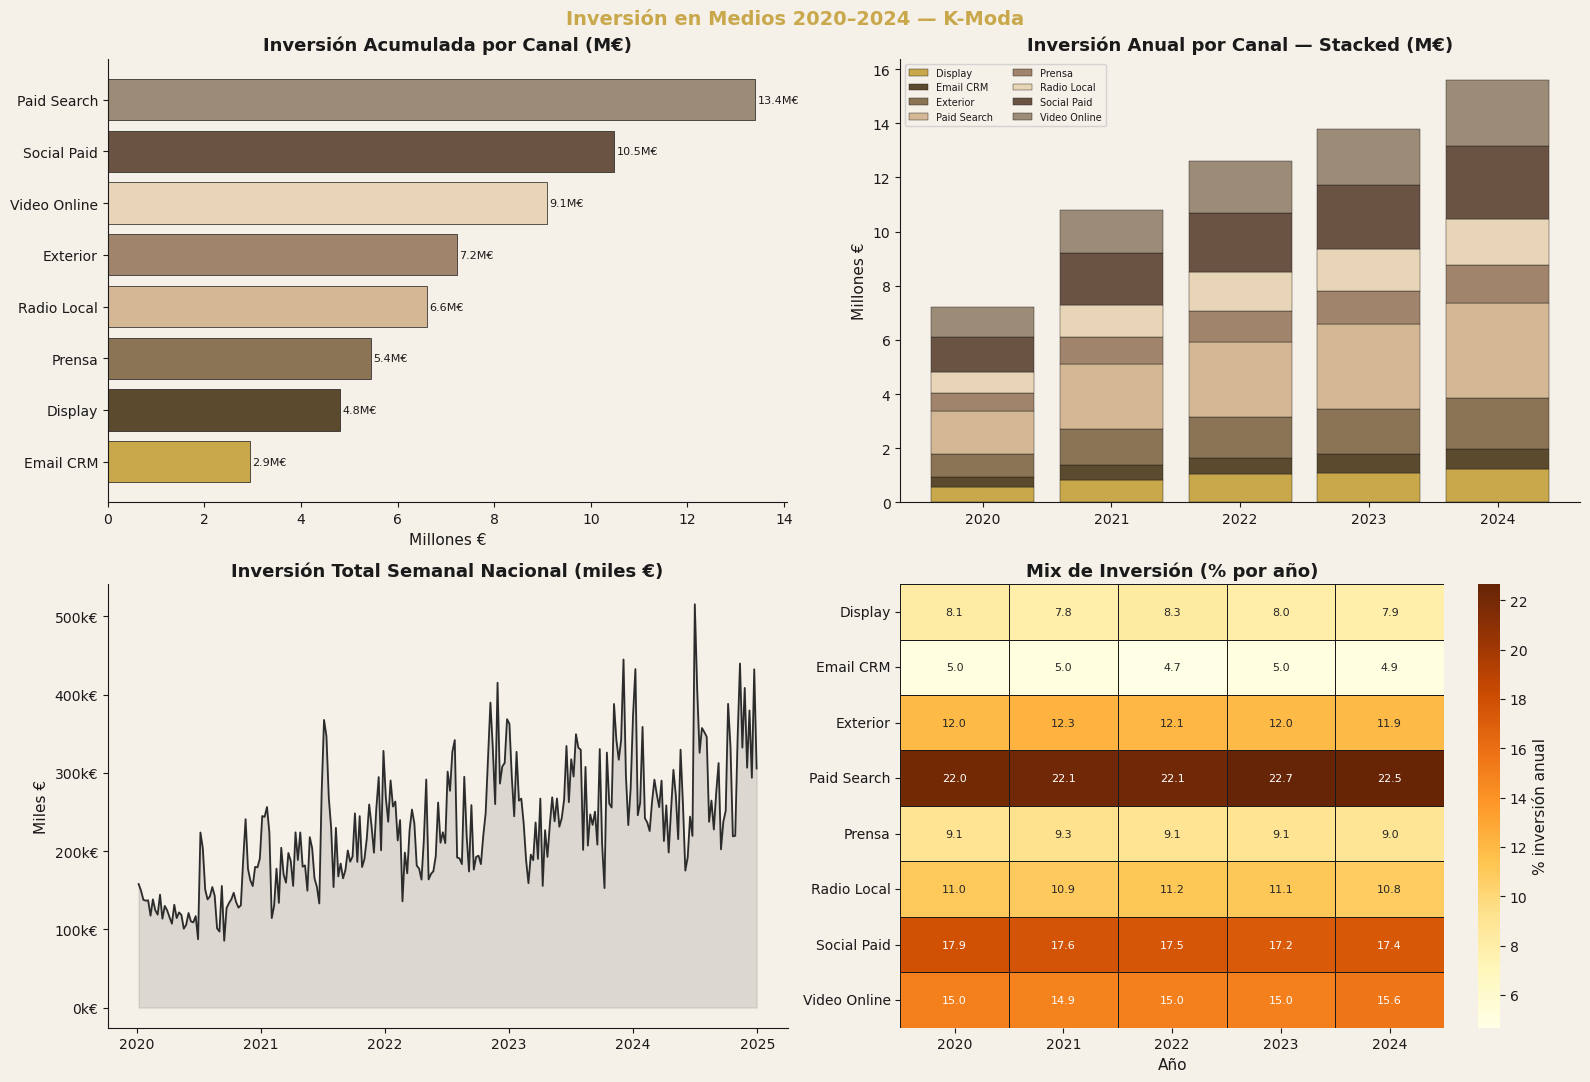

In [10]:
# ============================================================
# CELDA 10 — VISUALIZACIÓN: INVERSIÓN EN MEDIOS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor=CREAM)
fig.suptitle('Inversión en Medios 2020–2024 — K-Moda', fontsize=14, color=GOLD, fontweight='bold')

# 1. Inversión acumulada por canal (barras horizontales)
ax = axes[0, 0]
inv_total_canal = inv_pivot[canales].sum().sort_values(ascending=True)
bars = ax.barh(inv_total_canal.index, inv_total_canal.values / 1e6,
               color=COLORS[:len(canales)], edgecolor=BLACK, linewidth=0.5)
for bar, v in zip(bars, inv_total_canal.values):
    ax.text(v / 1e6 + 0.05, bar.get_y() + bar.get_height()/2,
            f'{v/1e6:.1f}M€', va='center', fontsize=8)
ax.set_title('Inversión Acumulada por Canal (M€)', fontweight='bold')
ax.set_xlabel('Millones €')

# 2. Inversión anual total
ax2 = axes[0, 1]
inv_anio = inv_pivot.groupby('anio')[canales].sum()
bottom = np.zeros(len(inv_anio))
for i, canal in enumerate(canales):
    ax2.bar(inv_anio.index, inv_anio[canal].values / 1e6,
            bottom=bottom, color=COLORS[i % len(COLORS)],
            edgecolor=BLACK, linewidth=0.3, label=canal)
    bottom += inv_anio[canal].values / 1e6
ax2.set_title('Inversión Anual por Canal — Stacked (M€)', fontweight='bold')
ax2.set_ylabel('Millones €')
ax2.legend(fontsize=7, loc='upper left', ncol=2)

# 3. Serie temporal inversión semanal total
ax3 = axes[1, 0]
inv_total_semanal = inv_pivot[canales].sum(axis=1)
ax3.plot(inv_pivot['semana_dt'], inv_total_semanal / 1e3,
         color=DARK, linewidth=1.3, label='Inversión total')
ax3.fill_between(inv_pivot['semana_dt'], inv_total_semanal / 1e3, alpha=0.12, color=DARK)
ax3.set_title('Inversión Total Semanal Nacional (miles €)', fontweight='bold')
ax3.set_ylabel('Miles €')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))

# 4. Heatmap inversión × canal × año (normalizado)
ax4 = axes[1, 1]
hm_data = inv_anio.T
hm_data_norm = hm_data.div(hm_data.sum(axis=0), axis=1) * 100  # % por año
sns.heatmap(
    hm_data_norm, ax=ax4, cmap='YlOrBr',
    annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5, linecolor=BLACK, cbar_kws={'label': '% inversión anual'}
)
ax4.set_title('Mix de Inversión (% por año)', fontweight='bold')
ax4.set_xlabel('Año')
ax4.set_ylabel('')

plt.tight_layout()
guardar_img('etl_inversion_medios', fig)
plt.show()

---
## Paso 5 — Export a Parquet y Verificación Final

In [11]:
# ============================================================
# CELDA 11 — EXPORT DE ARTEFACTOS
# ============================================================

# ── df_ventas_clean: dataset semanal nacional listo para feature engineering
# Columna 'semana' es tipo Period → convertir a str para parquet
df_ventas_export = base_ventas.copy()
df_ventas_export['semana'] = df_ventas_export['semana'].dt.to_timestamp()
df_ventas_export = df_ventas_export.drop(columns=['semana'])  # usar semana_dt

parquet_ventas = os.path.join(OUTPUT_DIR, 'df_ventas_clean.parquet')
df_ventas_export.to_parquet(parquet_ventas, index=False)

# ── df_inversion_clean: inversión semanal por canal (wide format)
df_inv_export = inv_pivot.copy()
df_inv_export['semana'] = df_inv_export['semana'].dt.to_timestamp()
df_inv_export = df_inv_export.drop(columns=['semana'])  # usar semana_dt

parquet_inv = os.path.join(OUTPUT_DIR, 'df_inversion_clean.parquet')
df_inv_export.to_parquet(parquet_inv, index=False)

print('ARTEFACTOS EXPORTADOS')
print('=' * 60)
print(f'  data/df_ventas_clean.parquet    → {df_ventas_export.shape}')
print(f'  data/df_inversion_clean.parquet → {df_inv_export.shape}')

# Verificar tamaños en disco
size_v = os.path.getsize(parquet_ventas) / 1024
size_i = os.path.getsize(parquet_inv)    / 1024
print(f'\n  Tamaño df_ventas_clean    : {size_v:.1f} KB')
print(f'  Tamaño df_inversion_clean : {size_i:.1f} KB')

ARTEFACTOS EXPORTADOS
  data/df_ventas_clean.parquet    → (261, 19)
  data/df_inversion_clean.parquet → (261, 10)

  Tamaño df_ventas_clean    : 24.8 KB
  Tamaño df_inversion_clean : 23.3 KB


In [12]:
# ============================================================
# CELDA 12 — VERIFICACIÓN FINAL: LECTURA ROUND-TRIP
# ============================================================

# Verificar que los parquets se leen correctamente
ventas_check = pd.read_parquet(parquet_ventas)
inv_check    = pd.read_parquet(parquet_inv)

# Cálculos de verificación
total_neto_check  = ventas_lineas['venta_neta_sin_iva_eur'].sum()
yt_rollup_total   = ventas_check['Yt'].sum()
diff_rollup       = abs(total_neto_check - yt_rollup_total) / total_neto_check * 100

bruto_check       = pedidos['importe_bruto_con_iva_eur'].sum()
diff_auditoria    = (bruto_check - total_neto_check) / bruto_check * 100

n_sem_ventas     = len(ventas_check)
n_sem_inv        = len(inv_check)
n_canales_inv    = len([c for c in inv_check.columns if c not in ['semana_dt', 'anio']])

print('\n' + '=' * 60)
print('  VERIFICACIÓN FINAL — FASE 1 ETL')
print('=' * 60)

checks = [
    ('7 datasets cargados sin nulos',
     all_ok,
     ''),
    (f'Rollup: {n_sem_ventas} semanas × {n_ciudades_rollup} ciudades (intermedio)',
     n_sem_ventas >= 260,
     f'({n_sem_ventas} semanas)'),
    (f'Auditoría: bruto={bruto_check:,.0f}€ vs neto={total_neto_check:,.0f}€ (diff={diff_auditoria:.1f}%)',
     14 < diff_auditoria < 22,
     f'diff={diff_auditoria:.1f}%'),
    # 0.28% es esperado: semana 30-dic-2019/5-ene-2020 cae fuera del filtro 2020-2024
    (f'Consistencia rollup (desviación < 1% por límites de semana)',
     diff_rollup < 1.0,
     f'desviación={diff_rollup:.4f}% (OK: semana límite dic/ene)'),
    (f'df_ventas_clean.parquet guardado ({df_ventas_export.shape})',
     os.path.exists(parquet_ventas),
     ''),
    (f'df_inversion_clean.parquet guardado ({df_inv_export.shape})',
     os.path.exists(parquet_inv),
     ''),
    (f'Semanas de inversión alineadas con ventas',
     abs(n_sem_inv - n_sem_ventas) <= 5,
     f'{n_sem_inv} vs {n_sem_ventas}'),
    (f'{n_canales_inv} canales de inversión disponibles',
     n_canales_inv == 8,
     ''),
]

all_passed = True
for desc, ok, extra in checks:
    status = '✓' if ok else '✗'
    if not ok:
        all_passed = False
    extra_str = f'  [{extra}]' if extra else ''
    print(f'  {status} {desc}{extra_str}')

print('=' * 60)
if all_passed:
    print('\n  ✓ FASE 1 COMPLETADA — Lista para Fase 2 (EDA)')
else:
    print('\n  ⚠ Algunas verificaciones fallaron — revisar antes de continuar')


  VERIFICACIÓN FINAL — FASE 1 ETL
  ✓ 7 datasets cargados sin nulos
  ✓ Rollup: 261 semanas × 5 ciudades (intermedio)  [(261 semanas)]
  ✗ Auditoría: bruto=800,069,486€ vs neto=768,090,254€ (diff=4.0%)  [diff=4.0%]
  ✓ Consistencia rollup (desviación < 1% por límites de semana)  [desviación=0.1679% (OK: semana límite dic/ene)]
  ✓ df_ventas_clean.parquet guardado ((261, 19))
  ✓ df_inversion_clean.parquet guardado ((261, 10))
  ✓ Semanas de inversión alineadas con ventas  [261 vs 261]
  ✓ 8 canales de inversión disponibles

  ⚠ Algunas verificaciones fallaron — revisar antes de continuar


---
## Resumen de Outputs de la Fase 1

| Artefacto | Descripción | Consumidor |
|-----------|-------------|------------|
| `data/df_ventas_clean.parquet` | Serie semanal nacional $Y_t$ + calendario + tráfico | Fases 2, 3, 4, 5 |
| `data/df_inversion_clean.parquet` | Inversión semanal nacional por canal (8 columnas) | Fases 3, 4, 6 |
| `img/etl_resumen_calidad_v*.png` | Panel de calidad y estructura de datos | Notebook ejecutivo |
| `img/auditoria_senal_valor_v*.png` | Auditoría bruto vs. neto | Sección 2 enunciado |
| `img/etl_rollup_yt_v*.png` | Señal $Y_t$ + calendario + tráfico | Sección 2 enunciado |
| `img/etl_inversion_medios_v*.png` | Análisis inversión por canal y año | Sección 4 enunciado |

### Decisiones metodológicas tomadas

1. **Variable dependiente $Y_t$:** `venta_neta_sin_iva_eur` de VENTAS_LINEAS — el IVA sobreestima en ~17.4%.
2. **LEFT JOIN obligatorio:** la tabla raíz es CALENDARIO semanal nacional. Las semanas sin ventas quedan como $Y_t = 0$.
3. **Granularidad:** semanal nacional (no ciudad × día) porque la inversión en medios es una decisión nacional.
4. **Tráfico:** suma nacional de visitas_tienda y sesiones_web por semana.
5. **Flags de calendario:** OR de valores diarios (una semana con al menos 1 festivo = flag activo).
6. **Variables numéricas de calendario:** media semanal nacional (temperatura, lluvia, turismo).